<a href="https://colab.research.google.com/github/cristianzucconi2-web/deep_learning/blob/main/Phi3_5_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

from unsloth import FastLanguageModel
import torch
import pandas as pd
from datasets import Dataset

# 1. Carichiamo Phi-3.5 Mini (3.8B) - Leggermente più grande di Llama 3.2 3B
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Phi-3.5-mini-instruct",
    max_seq_length = 2048,
    load_in_4bit = True,   # comprime il modello rendendolo quattro volte più leggero
)

# 2. Configurazione LoRA specifica per l'architettura Phi
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, #quanti nuovi parametri stiamo aggiungendo
    # Aggiungiamo tutti i moduli necessari per Phi-3.5
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)
#q_proj, k_proj, v_proj, o_proj: Sono i moduli dell'Attention, servono al modello per capire quali parole del tweet sono correlate tra loro (es. capire che "bello" è ironico se riferito a "disastro").
#gate_proj, up_proj, down_proj: Sono i moduli della rete neurale che elaborano le informazioni.
print("✅ Modello Phi-3.5 e LoRA caricati con successo!")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-9j9wt4d9/unsloth_aa782e17cfca4368aa05efdf7857f4eb
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-9j9wt4d9/unsloth_aa782e17cfca4368aa05efdf7857f4eb
  Resolved https://github.com/unslothai/unsloth.git to commit a6fe743ebe8055142eedba8cbbf9f62fc676a571
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 223.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 161.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 203.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.9/402.9 kB 224.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 267.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 261.7 MB/s eta 0:00:

model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

Unsloth 2026.3.15 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ Modello Phi-3.5 e LoRA caricati con successo!


In [ ]:
# Scarichiamo il repository GitHub per avere i file
!git clone https://github.com/Cyvhee/SemEval2018-Task3.git
print("✅ Cartelle scaricate con successo!")

Cloning into 'SemEval2018-Task3'...
remote: Enumerating objects: 315, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 315 (delta 0), reused 0 (delta 0), pack-reused 312 (from 1)
Receiving objects: 100% (315/315), 681.37 KiB | 2.36 MiB/s, done.
Resolving deltas: 100% (142/142), done.
✅ Cartelle scaricate con successo!


In [ ]:
import pandas as pd
import re
from datasets import Dataset

# Il percorso rimane lo stesso
path_train = 'SemEval2018-Task3/datasets/train/SemEval2018-T3-train-taskA_emoji.txt'

try:
    df = pd.read_csv(path_train, sep='\t')
    if 'tweet text' not in df.columns:
        df = pd.read_csv(path_train, sep='\t', header=None, names=['index', 'label', 'tweet text'])

    # Pulizia righe non valide (header residui)
    df = df[df['label'].astype(str).str.contains('0|1')].copy() #Rimuove eventuali righe sporche
    print(f" Dataset caricato con successo! Righe valide: {len(df)}")
except Exception as e:
    print(f" Errore: {e}")

# Pulizia (Identica a Llama)
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) #cancella link
    text = re.sub(r'@\w+', '', text)  #cancella tag
    return text.strip()

df['tweet text'] = df['tweet text'].apply(clean_tweet)

# --- TRADUZIONE PER PHI-3.5 ---
# il linguaggio dei tag usa un formato stile XML
def format_instruct_phi(row):
    return f"<s><|system|>\nYou are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>\n" \
           f"<|user|>\nTweet: {row['tweet text']}<|end|>\n" \
           f"<|assistant|>\n{row['label']}<|end|>\n"

df['formatted_text'] = df.apply(format_instruct_phi, axis=1) #Applica la formattazione a tutte le righe del database.
dataset = Dataset.from_pandas(df[['formatted_text']]) #Converte la tabella Pandas nel formato Dataset della libreria HuggingFace

print(f" Dataset pronto per Phi-3.5! Numero esempi: {len(dataset)}")
print("-" * 30)
print("Esempio di prompt Phi-3.5:")
print(dataset[0]['formatted_text'])

✅ Dataset caricato con successo! Righe valide: 3817
✅ Dataset pronto per Phi-3.5! Numero esempi: 3817
------------------------------
Esempio di prompt Phi-3.5:
<s><|system|>
You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>
<|user|>
Tweet: Sweet United Nations video. Just in time for Christmas. #imagine #NoReligion<|end|>
<|assistant|>
1<|end|>



In [ ]:
# 1. Rimuoviamo la prima riga sporca (quella con 'label', 'tweet text')
df_clean = df.iloc[1:].copy()

# 2. Rifacciamo la formattazione con i tag di Phi-3.5
def format_instruct_phi_final(row):
    return f"<s><|system|>\nYou are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>\n" \
           f"<|user|>\nTweet: {row['tweet text']}<|end|>\n" \
           f"<|assstant|>\n{row['label']}<|end|>\n"

df_clean['formatted_text'] = df_clean.apply(format_instruct_phi_final, axis=1)

# 3. Aggiorniamo il dataset per Unsloth
dataset = Dataset.from_pandas(df_clean[['formatted_text']])

print(f" Dataset ripulito per Phi-3.5! Righe reali: {len(dataset)}")
print("-" * 30)
print("Controllo Esempio Finale (Tag corretti):")
print(dataset[0]['formatted_text'])

✅ Dataset ripulito per Phi-3.5! Righe reali: 3816
------------------------------
Controllo Esempio Finale (Tag corretti):
<s><|system|>
You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>
<|user|>
Tweet: We are rumored to have talked to Erv's agent... and the Angels asked about Ed Escobar... that's hardly nothing    ;)<|end|>
<|assistant|>
1<|end|>



In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# Fondamentale per Phi-3.5: configuriamo il tokenizer per gestire il padding correttamente
tokenizer.pad_token = tokenizer.eos_token  # uso il token EOS come padding per colmare i vuoti (mi serve per mandarli al modello in batch)
tokenizer.padding_side = "right" #aggiungo i riempitivi a destra

def formatting_prompts_func(examples):
    # Aggiungiamo esplicitamente l'EOS token alla fine di ogni esempio per Phi-3.5
    return [text + tokenizer.eos_token for text in examples["formatted_text"]]

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "formatted_text",
    formatting_func = formatting_prompts_func,  # assicura che ogni tweet finisca con un segnale di stop chiaro
    max_seq_length = 2048,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 4, #Significa che il modello vede 4 tweet alla volta,
        gradient_accumulation_steps = 4, #ma aggiorna la sua memoria solo dopo averne visti 16 ($4 \times 4$). Questo trucco serve a simulare un addestramento più grande senza far esplodere la memoria della scheda video T4.
        warmup_steps = 5,
        num_train_epochs = 3, # Manteniamo 3 epoche come per Llama
        learning_rate = 2e-4,  #È la velocità di apprendimento. Se è troppo alta, il modello "impazzisce"; se è troppo bassa, non impara nulla. 2e-4 è il valore ideale per LoRA.
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit", #ottimizzatore ad otto bit, per usare poca RAM mantendndo la precisione di calcolo
        weight_decay = 0.01, #sottrarre lo 1% del valore del peso ad ogni aggiornamento.
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
    ),
)

print(" Partenza! Phi-3.5 sta imparando.")
trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/3816 [00:00<?, ? examples/s]

🚀 Partenza! Se vedi la tabella con la 'Training Loss', Phi-3.5 sta imparando.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,816 | Num Epochs = 3 | Total steps = 717
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Step,Training Loss
1,5.999609
2,5.759321
3,6.091375
4,5.421018
5,4.757132
6,4.397008
7,3.814423
8,3.135428
9,2.789991
10,2.524195


In [ ]:
import pandas as pd
import re
import torch
from tqdm import tqdm

# 1. Carichiamo il file di test (uguale)
path_test = 'SemEval2018-Task3/datasets/goldtest_TaskA/SemEval2018-T3_gold_test_taskA_emoji.txt'
test_df = pd.read_csv(path_test, sep='\t')
if 'tweet text' not in test_df.columns:
    test_df = pd.read_csv(path_test, sep='\t', header=None, names=['index', 'label', 'tweet text'])

def clean_test(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    return text.strip()

test_df['tweet text'] = test_df['tweet text'].apply(clean_test)

model.eval()

predictions = []
print(f" Analisi di {len(test_df)} tweet con Phi-3.5 (Safe Mode)...")

with torch.no_grad():
    for text in tqdm(test_df['tweet text']):
        # Prompt corretto per Phi-3.5
        prompt = f"<s><|system|>\nYou are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>\n<|user|>\nTweet: {text}<|end|>\n<|assistant|>\n"

        # Tokenizzazione senza padding per evitare conflitti di maschera
        inputs = tokenizer(prompt, return_tensors="pt", padding=False).to("cuda")  #trasforma le tue parole in numeri (id) che il modello può elaborare

        # GENERAZIONE NATIVA (evitiamo i parametri che triggerano il bug di Unsloth)
        outputs = model.generate(
            input_ids = inputs.input_ids,
            attention_mask = inputs.attention_mask,
            max_new_tokens = 1, # Chiediamo solo un token
            use_cache = False,  # DISATTIVIAMO LA CACHE: più lento ma evita il RuntimeError
            pad_token_id = tokenizer.eos_token_id,
            temperature = 0.01, # rendo il modello deterministico in modo rtale che se gli faccio la stessa domanda mi da la stessa risposta
            do_sample = False
        )

        # Decodifica dell'ultimo token generato
        response = tokenizer.decode(outputs[0][-1:], skip_special_tokens=True)

        # Estrazione pulita
        if '1' in response:
            predictions.append(1)
        else:
            predictions.append(0)

test_df['prediction'] = predictions
print("\n✅ Analisi completata senza errori!")

🧐 Analisi di 785 tweet con Phi-3.5 (Safe Mode)...


  0%|          | 0/785 [00:00<?, ?it/s]Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fu


✅ Analisi completata senza errori!


======= 📊 RISULTATI FINALI PHI-3.5 =======
ACCURACY TOTALE: 81.63%

REPORT DETTAGLIATO:
              precision    recall  f1-score   support

 Non Ironico       0.91      0.77      0.83       473
     Ironico       0.72      0.89      0.79       311

    accuracy                           0.82       784
   macro avg       0.81      0.83      0.81       784
weighted avg       0.83      0.82      0.82       784



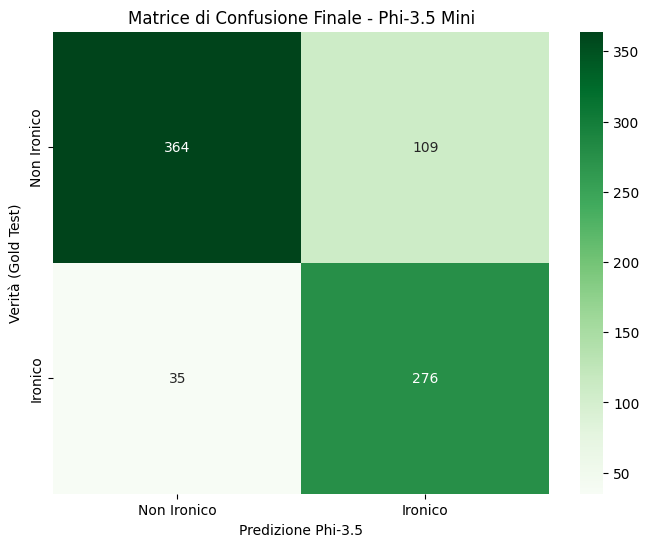

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pulizia: teniamo solo le righe con label 0 o 1 (rimuove l'header se presente)
test_df_clean = test_df[test_df['label'].astype(str).str.contains('0|1')].copy()

# 2. Conversione
y_true = test_df_clean['label'].astype(int)
y_pred = test_df_clean['prediction']

# 3. Calcolo parametri
accuracy = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=['Non Ironico', 'Ironico'])

print("======= 📊 RISULTATI FINALI PHI-3.5 =======")
print(f"ACCURACY TOTALE: {accuracy:.2%}")
print("\nREPORT DETTAGLIATO:")
print(report)

# Matrice di confusione
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Verde per Phi-3.5
            xticklabels=['Non Ironico', 'Ironico'],
            yticklabels=['Non Ironico', 'Ironico'])
plt.xlabel('Predizione Phi-3.5')
plt.ylabel('Verità (Gold Test)')
plt.title('Matrice di Confusione Finale - Phi-3.5 Mini')
plt.show()

In [ ]:
import torch
from unsloth import FastLanguageModel

# 1. DISATTIVIAMO I KERNEL OTTIMIZZATI CHE CAUSANO IL CRASH
# Questo resetta il modello in modalità standard Hugging Face
model = FastLanguageModel.for_inference(model)

def test_veloce_phi(tweet):
    # Prompt con tag corretti
    prompt = f"<s><|system|>\nYou are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|end|>\n<|user|>\nTweet: {tweet}<|end|>\n<|assistant|>\n"

    # Tokenizzazione
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # GENERAZIONE MANUALE SENZA CACHE (per evitare il bug del broadcast)
    with torch.no_grad():
        outputs = model.generate(
            input_ids = inputs.input_ids,
            attention_mask = inputs.attention_mask,
            max_new_tokens = 1, # Ci serve solo un numero
            use_cache = False,  # FONDAMENTALE: evita il bug della KV Cache
            pad_token_id = tokenizer.eos_token_id,
            temperature = 0.01,
            do_sample = False
        )

    # Decodifica dell'ultimo token generato
    risposta = tokenizer.decode(outputs[0][-1:], skip_special_tokens=True)

    # Pulizia risultato
    risultato = "1" if "1" in risposta else "0"
    label = "🔥 IRONICO (1)" if risultato == "1" else "✅ NON IRONICO (0)"

    print(f"Tweet: {tweet}")
    print(f"Sentenza: {label}")
    print("-" * 30)

# --- Test ---
test_veloce_phi("Amo tantissimo quando il treno ha 60 minuti di ritardo e io ho una riunione importante.")
test_veloce_phi("Oggi c'è un sole bellissimo e sono felice di andare al mare.")
test_veloce_phi("Mi piace tanto andare al parco")
test_veloce_phi("Bello perdere una finale al 90esimo, proprio un sogno")

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Amo tantissimo quando il treno ha 60 minuti di ritardo e io ho una riunione importante.
Sentenza: 🔥 IRONICO (1)
------------------------------


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Oggi c'è un sole bellissimo e sono felice di andare al mare.
Sentenza: ✅ NON IRONICO (0)
------------------------------


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Mi piace tanto andare al parco
Sentenza: ✅ NON IRONICO (0)
------------------------------
Tweet: Bello perdere una finale al 90esimo, proprio un sogno
Sentenza: 🔥 IRONICO (1)
------------------------------


In [ ]:
import torch

def test_severo_phi(tweet_text):
    # Usiamo le tue nuove istruzioni ma con i tag <s>, <|system|>, ecc.
    prompt = f"<s><|system|>\nYou are a balanced linguistic expert. Be careful: not every positive word is irony. " \
             f"Only answer 1 if you are sure there is a logical contradiction. Answer ONLY with 1 (Yes) or 0 (No).<|end|>\n" \
             f"<|user|>\nTweet: {tweet_text}<|end|>\n" \
             f"<|assistant|>\n"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            input_ids = inputs.input_ids,
            attention_mask = inputs.attention_mask,
            max_new_tokens = 1,
            use_cache = False,
            pad_token_id = tokenizer.eos_token_id,
            temperature = 0.01,
            do_sample = False
        )

    risposta = tokenizer.decode(outputs[0][-1:], skip_special_tokens=True)
    risultato = "1" if "1" in risposta else "0"
    label = " IRONICO (1)" if risultato == "1" else " NON IRONICO (0)"
    print(f"Tweet: {tweet_text} -> Sentenza: {label}")

# --- ESECUZIONE 5+5 ---
print("--- ⚖️ TEST PHI-3.5 CON PROMPT SEVERO (5+5) ---")
for sentence in test_sentences_final:
    test_severo_phi(sentence)

Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- ⚖️ TEST PHI-3.5 CON PROMPT SEVERO (5+5) ---


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: Splendid! My computer crashed right before I saved my 20-page report. -> Sentenza: 🔥 IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Tweet: It was a very long day, but I feel satisfied with what I achieved. So good -> Sentenza: 🔥 IRONICO (1)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: The garden looks lovely now that all the flowers are blooming. -> Sentenza: ✅ NON IRONICO (0)


Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tweet: The food was delicious, I recommend it. -> Sentenza: ✅ NON IRONICO (0)
Tweet: I finished the project and I can relax for the weekend. -> Sentenza: ✅ NON IRONICO (0)


LoRA permette di fare il fine-tuning su una GPU piccola come quella di Colab (senza di lui il computer esploderebbe per mancanza di memoria).

AdamW assicura che questo fine-tuning avvenga in modo intelligente, preciso e senza sporcare i pesi (grazie al weight decay).